In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("Loading data and model...")
# 1. Load Data
df = pd.read_csv('../data/processed/heart_cleaned.csv')
X = df.drop(columns=['target'])
y = df['target']

# 2. Recreate the exact same test split
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Load Samuel's Scaler and Mpho's Random Forest Model
scaler = joblib.load('../models/scaler.pkl')
rf_model = joblib.load('../models/rf_model.pkl')

# 4. Scale the test data so SHAP can read it properly
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
print("Ready for SHAP!")

C:\Users\jides\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data and model...
Ready for SHAP!


Calculating SHAP values (this might take a few seconds)...


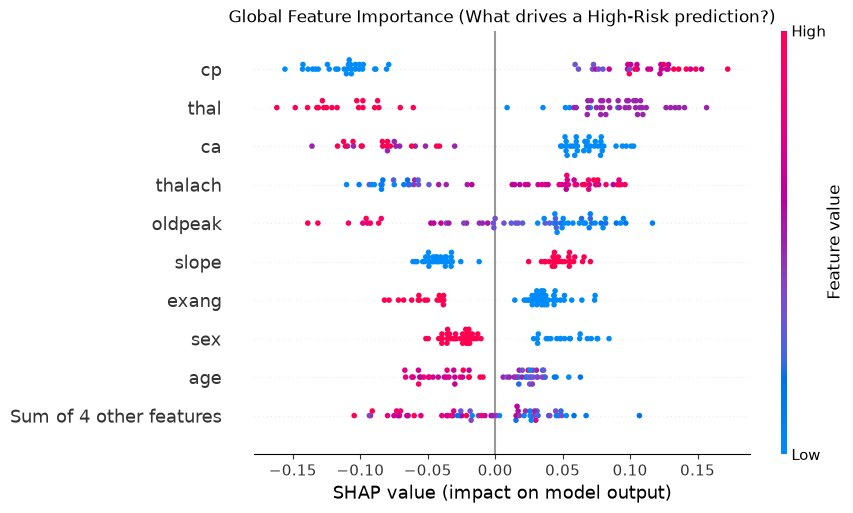

In [2]:
print("Calculating SHAP values (this might take a few seconds)...")
# Initialize the SHAP Explainer using the Random Forest model
explainer = shap.Explainer(rf_model)
shap_values = explainer(X_test_scaled)

# Generate a global summary plot for High-Risk predictions (Class 1)
plt.title("Global Feature Importance (What drives a High-Risk prediction?)")
shap.plots.beeswarm(shap_values[:, :, 1])

Generating explanation for Patient #0...


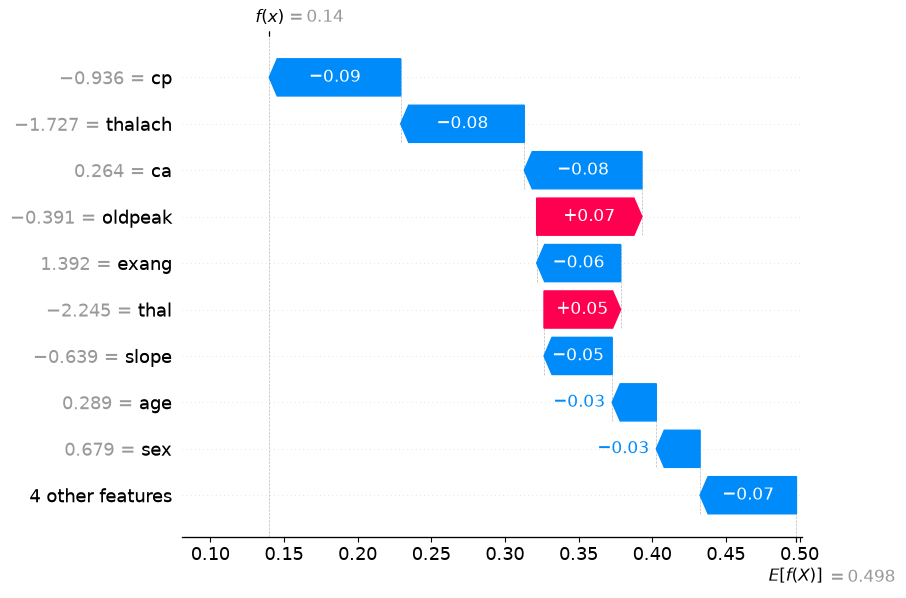

In [3]:
# Select a specific patient (Patient 0 from our test set)
patient_index = 0

print(f"Generating explanation for Patient #{patient_index}...")

# Generate a waterfall plot for this specific patient's High-Risk prediction
shap.plots.waterfall(shap_values[patient_index, :, 1])